In [1]:
# simple linear regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression")

Using Colab cache for faster access to the 'student-performance-multiple-linear-regression' dataset.


In [29]:
df = pd.read_csv(path+f'/Student_Performance.csv')

In [30]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [31]:
df = df[['Previous Scores', 'Performance Index']]

In [32]:
df.head()

,Previous Scores,Performance Index
0,99,91.0
1,82,65.0
2,51,45.0
3,52,36.0
4,75,66.0


In [36]:
df.columns = ['Scores', 'Performance']

In [37]:
df.head()

,Scores,Performance
0,99,91.0
1,82,65.0
2,51,45.0
3,52,36.0
4,75,66.0


In [38]:
#plotting  to see whether they are sort of linear  or not

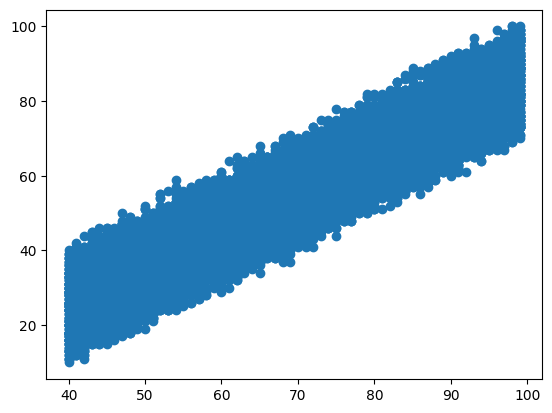

In [40]:
plt.scatter(df['Scores'], df['Performance'])

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(df['Scores'], df['Performance'], test_size= 0.2, random_state= 20)

In [44]:
from sklearn.linear_model import LinearRegression

In [45]:
lr = LinearRegression()

In [49]:
lr.fit(X_train.values.reshape(-1, 1), y_train)

LinearRegression()

In [50]:
lr.coef_

array([1.01458792])

In [51]:
lr.intercept_

np.float64(-15.281010187181153)

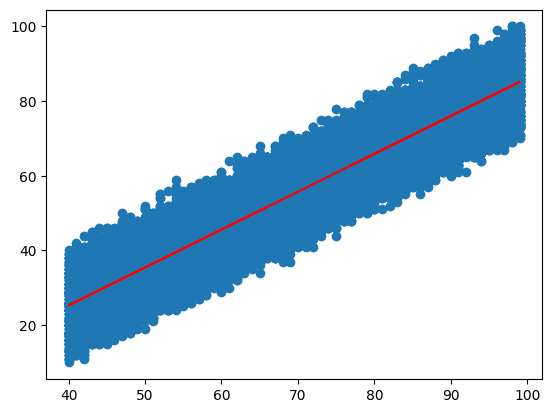

In [53]:
plt.scatter(df['Scores'], df['Performance'])
plt.plot(X_train, lr.predict(X_train.values.reshape(-1, 1)), color = 'red')

In [55]:
y_pred = lr.predict(X_test.values.reshape(-1, 1))

In [56]:
from sklearn.metrics import r2_score

In [57]:
r2_score(y_test, y_pred)

0.8363617687829799

In [58]:
# creating my own class

In [63]:
class SLR:

  def __init__(self):
    self.coeff_ = None
    self.intercept_ = None

  def fit(self, X_train, y_train):

    num = np.dot(X_train - np.mean(X_train), y_train - np.mean(y_train))
    den = np.sum(np.square(X_train - np.mean(X_train)))

    self.coeff_ = num / den
    self.intercept_ = np.mean(y_train) - (self.coeff_ * np.mean(X_train))

  def predict(self, X_test):
    return (self.coeff_ * X_test + self.intercept_)

In [64]:
lr2 = SLR()

In [65]:
lr2.fit(X_train.values, y_train.values)

In [66]:
lr2.coeff_

np.float64(1.0145879166059202)

In [67]:
lr2.intercept_

np.float64(-15.281010187181138)

In [68]:
np.sum(y_test.values - lr2.predict(X_test.values))

np.float64(470.4210694139024)

In [69]:
np.sum(np.square(y_test.values - lr2.predict(X_test.values)))

np.float64(119544.42758049567)

In [71]:
ssm = np.sum(np.square(y_test.values - np.mean(y_test.values)))

In [72]:
ssm

np.float64(730540.942)

In [73]:
ssr = np.sum(np.square(y_test.values - lr2.predict(X_test.values)))

In [74]:
ssr

np.float64(119544.42758049567)

In [75]:
1- (ssr / ssm)

np.float64(0.8363617687829799)